# 09_聚类算法-期望最大化算法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今儿聊聊**期望最大化算法**，即EM算法\~

先说聚类是什么？聚类就是：**把一堆乱七八糟的数据，分成几组，让每一组里的数据都比较像彼此。**

比如你有100个水果的数据（颜色、大小、重量），你想自动把它们分成“苹果”“香蕉”“橘子”几类，但你事先又不知道哪一个是苹果、哪一个是香蕉，这就是**无监督学习**里的**聚类问题**。

#### 那EM算法是干嘛的？

EM算法（Expectation-Maximization）是一个**解决“有点模糊不清”的聚类问题的办法**。

它最适合的情况是：你猜测这些数据背后有几类（比如猜有3类水果），而且你还猜测这些数据是从某种“概率分布”中出来的（比如高斯分布，像钟形曲线那种），但你**不知道具体是哪一类的**，也**不知道每一类的参数是啥**（比如中心在哪里，胖不胖之类的）。

那怎么办？EM算法说：**那就先猜一下，然后一步一步去优化！**

#### EM算法的大白话流程

EM算法主要有两个步骤，不断来回交替：

**1. E步（期望步 Expectation）：**

在这一步里，你**根据当前的猜测（每一类的参数）**，来推测每个数据点**属于哪一类的可能性**有多大。

比如：这个水果是红的，圆的，那大概率是苹果；那个黄的，长的，可能是香蕉。

这个“属于某一类的概率”就叫做**软分类**（不像K-means那种“非苹果即香蕉”，它是“80%像苹果，20%像香蕉”）。

**2. M步（最大化步 Maximization）：**

在这一步里，你根据上一步算出来的“分类概率”，来**重新估计每一类的参数**（比如中心在哪、大小是多少等）。

比如你根据“谁像苹果”来重新算出苹果的平均颜色、大小、重量等。

#### 然后不断重复上面两步，直到稳定

也就是说：

> 猜一猜 → 重新估参数 → 再猜一猜 → 再优化参数 → …

> 一直循环，直到结果不再变化（或者变化很小）。

#### 举个形象的例子：

假设你在黑暗房间里抓了三种水果（苹果、香蕉、橙子），但你不知道哪一个是哪一个，只能摸摸看（有点信息）。EM算法的过程就像：

1. 你先猜：这可能是苹果，那可能是香蕉。
2. 然后你根据“哪个摸起来像香蕉的多”来重新总结“香蕉大概摸起来是什么样”。
3. 然后再用这个标准去重新猜每个水果的类型。
4. 不断重复，直到你很有信心谁是谁。

## 原理详解

### 一、问题背景与建模动机

我们设有一组观测数据：


$$
\mathcal{X} = \{x_1, x_2, \dots, x_N\}
$$


这些数据被假设是由 $K$个不同的概率分布混合生成的。我们不知道每一个数据点来自哪个分布（类别），即类别标签是**不可观测的隐藏变量**。

例如，在高斯混合模型（GMM）中，每个数据点是由某个高斯分布（类别）生成的，而类别标签是隐藏的。

我们定义以下内容：

- $x_i$：第 $i$个观测数据点
- $z_i$：第 $i$个样本对应的隐藏变量（表示它来自哪个类别，取值在 $\{1, 2, \dots, K\}$之间）
- $\theta$：模型的参数集合，包括每个类别的概率（混合系数）、均值和协方差等（在GMM中）

我们的任务是：

在只观测到 $\{x_i\}_{i=1}^N$的情况下，估计参数 $\theta$。

这就是一个**含有隐藏变量的最大似然估计问题**，EM算法专为此类问题设计。

### 二、最大似然估计的挑战

完整数据的联合概率为：


$$
p(x_i, z_i \mid \theta) = p(z_i \mid \theta) \cdot p(x_i \mid z_i, \theta)
$$


但我们只能观测到 $x_i$，因此我们只能计算边缘概率：


$$
p(x_i \mid \theta) = \sum_{z_i} p(x_i, z_i \mid \theta)
$$


于是，对数似然函数为：


$$
\log p(\mathcal{X} \mid \theta) = \sum_{i=1}^{N} \log \sum_{z_i} p(x_i, z_i \mid \theta)
$$


问题是，这个对数和内部含有求和运算，难以直接优化（特别是在参数更新时难以求导）。

### 三、引入EM算法的动机与变分思想

为了解决这个优化困难，EM算法采用了变分思想，引入一个对隐藏变量分布的估计 $q(z)$，并通过Jensen不等式将难以优化的对数似然函数转化为可优化的下界。

#### Jensen不等式推导过程

我们从单个样本 $x$出发，考虑其边缘对数似然：


$$
\log p(x \mid \theta) = \log \sum_{z} p(x, z \mid \theta)
$$


引入任意分布 $q(z)$，写作：


$$
\log p(x \mid \theta) = \log \sum_z q(z) \frac{p(x, z \mid \theta)}{q(z)} \geq \sum_z q(z) \log \frac{p(x, z \mid \theta)}{q(z)}
$$


这个下界记作：


$$
\mathcal{L}(q, \theta) = \sum_z q(z) \log \frac{p(x, z \mid \theta)}{q(z)}
$$


当 $q(z) = p(z \mid x, \theta)$时，这个不等号取等，意味着我们可以通过优化这个下界来间接优化原始似然函数。

### 四、EM算法的步骤

EM算法通过交替优化 $q(z)$与 $\theta$，不断提高上述下界，从而提高对数似然。

设模型参数为 $\theta$，隐藏变量为 $Z$，观测数据为 $X$。

EM算法的两大步骤为：

#### E步（Expectation step）：

在当前参数 $\theta^{(t)}$下，计算隐藏变量的**后验分布**：


$$
q^{(t)}(z_i) := p(z_i \mid x_i, \theta^{(t)})
$$


这个过程就是计算“在当前参数下，观测到 $x_i$时，属于每个类别的概率”。

对于高斯混合模型：


$$
\gamma_{ik} := p(z_i = k \mid x_i, \theta^{(t)}) = \frac{\pi_k^{(t)} \cdot \mathcal{N}(x_i \mid \mu_k^{(t)}, \Sigma_k^{(t)})}{\sum_{j=1}^{K} \pi_j^{(t)} \cdot \mathcal{N}(x_i \mid \mu_j^{(t)}, \Sigma_j^{(t)})}
$$


其中，$\gamma_{ik}$表示“第 $i$个样本属于第 $k$个类别的概率”。

#### M步（Maximization step）：

固定 $q^{(t)}(z)$，最大化期望下的完整数据对数似然：


$$
\theta^{(t+1)} = \arg\max_{\theta} \mathbb{E}_{q^{(t)}}[\log p(X, Z \mid \theta)]
$$


对于高斯混合模型，这等价于最大化：


$$
Q(\theta, \theta^{(t)}) = \sum_{i=1}^{N} \sum_{k=1}^{K} \gamma_{ik} \log \left( \pi_k \cdot \mathcal{N}(x_i \mid \mu_k, \Sigma_k) \right)
$$


接下来分别对每个参数进行求导并令导数为零，得到更新公式。

### 五、参数更新推导（以高斯混合模型为例）

我们记：


$$
N_k := \sum_{i=1}^{N} \gamma_{ik}
$$


1. **更新混合系数**：


$$
\pi_k = \frac{N_k}{N}
$$


1. **更新均值**：


$$
\mu_k = \frac{1}{N_k} \sum_{i=1}^{N} \gamma_{ik} x_i
$$


1. **更新协方差矩阵**：


$$
\Sigma_k = \frac{1}{N_k} \sum_{i=1}^{N} \gamma_{ik} (x_i - \mu_k)(x_i - \mu_k)^T
$$


这些公式来自于对 $Q(\theta, \theta^{(t)})$对每个参数求偏导并令导数为零所得。

### 六、EM算法流程总结

1. 初始化参数 $\theta^{(0)} = \{\pi_k^{(0)}, \mu_k^{(0)}, \Sigma_k^{(0)}\}$
2. 重复以下步骤直到收敛（对数似然收敛或参数变化足够小）：

   - E步：计算每个样本属于每个类别的后验概率 $\gamma_{ik}$
   - M步：使用上述公式更新 $\pi_k, \mu_k, \Sigma_k$
3. 返回最终的参数和“软聚类”结果（每个样本属于每个类别的概率）

### 七、EM算法的性质

1. **每步迭代都不减小对数似然函数值**（由Jensen不等式与最大化Q函数保证）
2. **收敛性良好**，但只能保证收敛到局部最优
3. **对初值敏感**，通常需尝试多次初始值或结合K-means等启发式方法初始化
4. **适用于带隐藏变量的概率模型**，不仅限于GMM，也适用于隐马尔可夫模型（HMM）等

## 完整案例

这里，咱们通过一个二维混合高斯数据的实际案例，手动实现EM算法，并结合`scikit-learn`的`GaussianMixture`作对比。

### 数据准备

生成一个包含3个不同高斯簇的数据集，每个簇具有不同的均值和协方差：

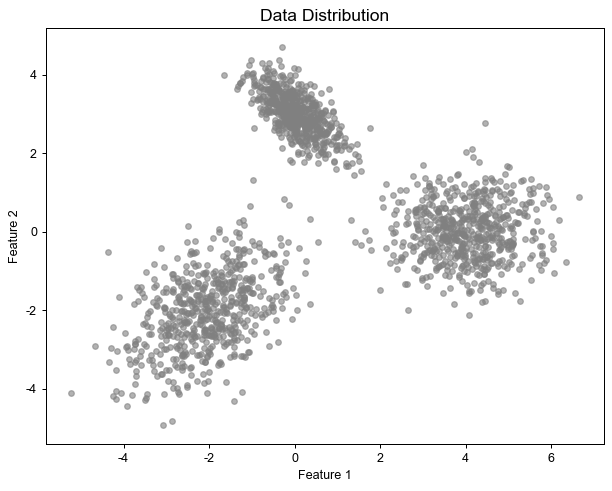

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)

# 定义3个高斯分布的均值和协方差
means = [(-2, -2), (0, 3), (4, 0)]
covariances = [ [[1.0, 0.5], [0.5, 1.0]],
                [[0.3, -0.2], [-0.2, 0.3]],
                [[0.8, 0], [0, 0.5]] ]

# 采样
X = np.vstack([
    np.random.multivariate_normal(mean, cov, size=600)
    for mean, cov in zip(means, covariances)
])

# 可视化原始数据
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=20, c='gray', alpha=0.6)
plt.title("Data Distribution", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

生成了1800个样本，分布在3个椭圆形簇中。

灰色散点图展示了整体分布情况，为后续EM聚类提供数据基础。

![原文参考图，当前结果见代码输出](attachments/img_012.png)

### 手动实现EM算法

展示EM算法的向量化实现，包含初始化、E步、M步、收敛判断。

In [3]:
import numpy as np
from scipy.stats import multivariate_normal

class EMGaussianMixture:
    def __init__(self, n_components, max_iter=100, tol=1e-4, reg_covar=1e-6):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar

    def _initialize_parameters(self, X):
        n_samples, n_features = X.shape
        # 随机选择初始均值
        indices = np.random.choice(n_samples, self.n_components, replace=False)
        self.means_ = X[indices]
        # 初始化协方差为样本协方差
        self.covariances_ = np.array([np.cov(X, rowvar=False)] * self.n_components)
        # 均匀初始化混合系数
        self.weights_ = np.ones(self.n_components) / self.n_components

    def _e_step(self, X):
        # 计算responsibilities
        weighted_pdfs = np.zeros((X.shape[0], self.n_components))
        for k in range(self.n_components):
            rv = multivariate_normal(mean=self.means_[k], cov=self.covariances_[k])
            weighted_pdfs[:, k] = self.weights_[k] * rv.pdf(X)
        sum_pdfs = weighted_pdfs.sum(axis=1, keepdims=True)
        responsibilities = weighted_pdfs / sum_pdfs
        return responsibilities

    def _m_step(self, X, resp):
        Nk = resp.sum(axis=0)
        self.weights_ = Nk / X.shape[0]
        self.means_ = (resp.T @ X) / Nk[:, np.newaxis]
        for k in range(self.n_components):
            diff = X - self.means_[k]
            self.covariances_[k] = (resp[:, k][:, np.newaxis] * diff).T @ diff / Nk[k]
            # 协方差正则化
            self.covariances_[k] += self.reg_covar * np.eye(X.shape[1])

    def _compute_lower_bound(self, X):
        log_prob = np.zeros((X.shape[0], self.n_components))
        for k in range(self.n_components):
            rv = multivariate_normal(mean=self.means_[k], cov=self.covariances_[k])
            log_prob[:, k] = np.log(self.weights_[k] + 1e-10) + rv.logpdf(X)
        # 对数似然
        return np.mean(np.logaddexp.reduce(log_prob, axis=1))

    def fit(self, X):
        self._initialize_parameters(X)
        lower_bound_old = -np.inf
        self.converged_ = False
        for iteration in range(self.max_iter):
            resp = self._e_step(X)
            self._m_step(X, resp)
            lower_bound_new = self._compute_lower_bound(X)
            # 打印对数似然
            print(f"Iter {iteration}: Lower bound = {lower_bound_new:.6f}")
            if abs(lower_bound_new - lower_bound_old) < self.tol:
                self.converged_ = True
                break
            lower_bound_old = lower_bound_new
        return self

    def predict(self, X):
        resp = self._e_step(X)
        return np.argmax(resp, axis=1)

- `reg_covar`参数在协方差矩阵对角项加入微小值，避免奇异。
- `_initialize_parameters`采用随机样本作为初始簇中心。
- 向量化计算`responsibilities`，提高效率。
- 收敛标准基于对数似然增量小于`tol`。

### 可视化初始与迭代过程

EM的迭代过程，我们定义一个可视化函数，在每次M步后绘制簇中心和等高线\~

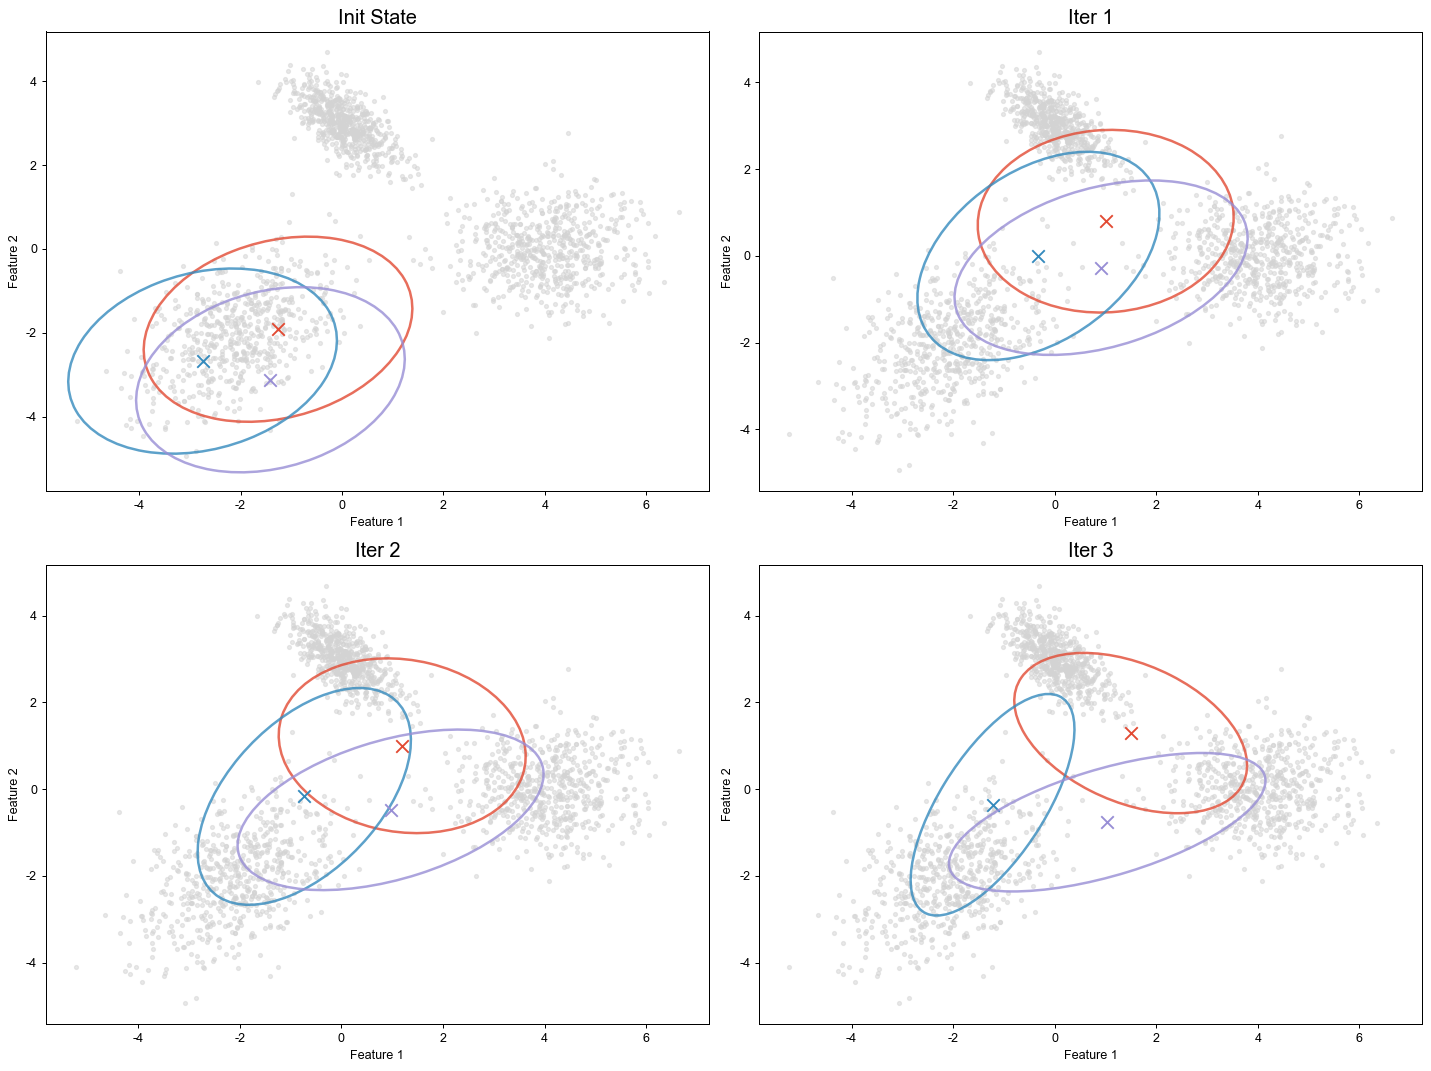

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# 可视化GMM当前状态
def plot_gmm(X, means, covariances, title="GMM State", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    # 绘制散点
    ax.scatter(X[:, 0], X[:, 1], s=10, c='lightgray', alpha=0.5)
    # 不同颜色
    colors = ['#E24A33', '#348ABD', '#988ED5', '#777777']
    for k, (mean, cov) in enumerate(zip(means, covariances)):
        # 绘制中心
        ax.scatter(mean[0], mean[1], marker='x', s=100, color=colors[k])
        # 绘制协方差椭圆
        vals, vecs = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)
        ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor=colors[k], fc='None', lw=2, alpha=0.8)
        ax.add_patch(ell)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

# 演示一次初始化和几次迭代
em = EMGaussianMixture(n_components=3, max_iter=10)
# 手动初始化参数
em._initialize_parameters(X)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_gmm(X, em.means_, em.covariances_, title="Init State", ax=axes[0,0])

for i in range(3):
    resp = em._e_step(X)
    em._m_step(X, resp)
    plot_gmm(X, em.means_, em.covariances_, title=f"Iter {i+1}", ax=axes[(i+1)//2, (i+1)%2])
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_013.png)

- 椭圆宽度和高度分别为两个主轴的两个标准差，展示了每个簇的形状。
- 每次迭代中，簇中心（×标记）和协方差椭圆不断调整，最终收敛。

### 对比`scikit-learn`实现 & 模型选择

利用`sklearn.mixture.GaussianMixture`进行自动化EM，并且采用BIC选择最佳簇数：

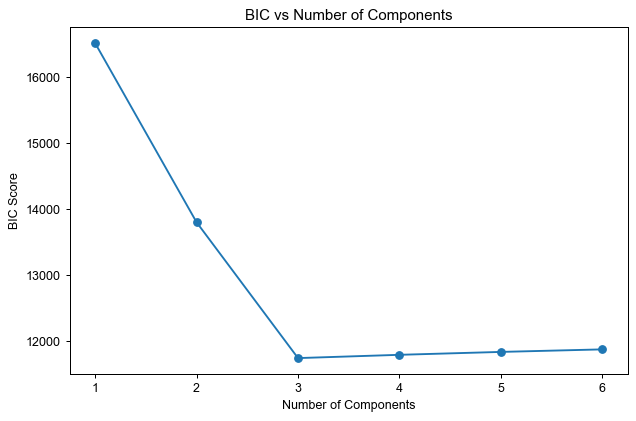

Optimal number of components by BIC: 3


In [5]:
from sklearn.mixture import GaussianMixture
import numpy as np

n_components_range = range(1, 7)
bics = []
for n in n_components_range:
    gmm = GaussianMixture(n, covariance_type='full', random_state=42)
    gmm.fit(X)
    bics.append(gmm.bic(X))

# 绘制BIC曲线
plt.figure(figsize=(8, 5))
plt.plot(n_components_range, bics, marker='o')
plt.title("BIC vs Number of Components")
plt.xlabel("Number of Components")
plt.ylabel("BIC Score")
plt.show()
# 选取BIC最小对应的n
best_n = n_components_range[np.argmin(bics)]
print(f"Optimal number of components by BIC: {best_n}")

![原文参考图，当前结果见代码输出](attachments/img_014.png)

- BIC（Bayesian Information Criterion）在模型复杂度和拟合度之间平衡，值越低越优。
- 上图显示BIC在簇数=3处达到最小，验证了实际数据生成过程。

### 算法优化策略

1. **KMeans初始化**：使用KMeans结果初始化GMM参数，提高收敛速度。
2. **向量化实现**：已在前述代码中体现，提高了E步和M步的计算效率。
3. **协方差正则化**：避免奇异矩阵，增强数值稳定性。
4. **并行加速**：`sklearn`的`GaussianMixture`支持`n_init`和`warm_start`，可多次初始化或增量训练。

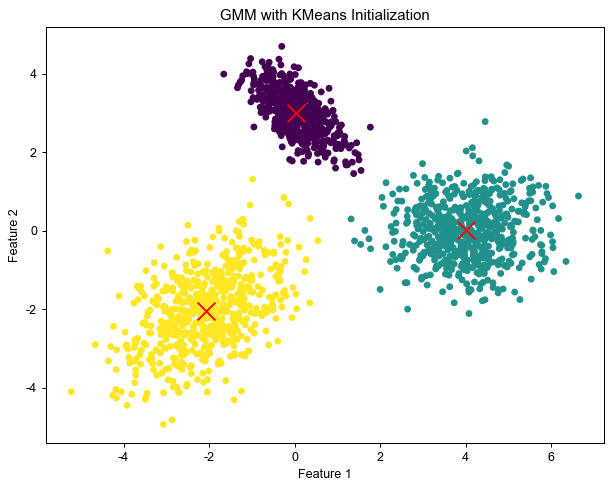

In [6]:
# KMeans初始化
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
init_means = kmeans.cluster_centers_

# 用初始化参数跑GMM
gmm_custom_init = GaussianMixture(n_components=3, covariance_type='full',
                                  means_init=init_means, random_state=42)
gmm_custom_init.fit(X)
labels = gmm_custom_init.predict(X)

# 可视化
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=20)
plt.scatter(init_means[:,0], init_means[:,1], marker='x', s=200, c='red')
plt.title("GMM with KMeans Initialization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_015.png)

- KMeans初始化可将簇中心快速收敛到合理位置，减少EM迭代次数。

整个案例，通过手动实现EM算法，我们深入理解了E步与M步的数学原理，并演示了簇中心和协方差的迭代变化过程。结合`scikit-learn`工具，我们采用BIC方法选择最佳簇数，并引入KMeans初始化、正则化、向量化等优化策略，大幅提升算法的收敛速度和数值稳定性。

## 模型分析

EM 算法尤其适用于高斯混合模型，它通过迭代优化期望函数，不断估计隐含变量和模型参数，来最大化观测数据的似然估计。

### EM聚类算法的优缺点

**优点：**

1. **适用于复杂分布模型**：EM算法特别适合用于**具有概率分布假设的数据**，如高斯分布。与K-Means只能处理球形簇不同，EM能处理**不同形状、方差的簇**。
2. **软聚类（Soft Clustering）**：与K-Means的硬划分不同，EM为每个数据点计算属于每个簇的**概率**，更能反映真实的归属不确定性。
3. **理论基础扎实**：有完整的统计学背景，适用于缺失数据场景；可以推广至**贝叶斯方法**。
4. **可扩展性**：EM框架可应用于其他模型，如隐马尔可夫模型（HMM）、主题模型（如LDA）等。

**缺点：**

1. **对初始值敏感**：EM极易陷入局部最优，初始参数的选择会显著影响聚类结果。
2. **需要指定簇数K**：与K-Means一样，需要预先设定簇的个数，缺乏自动选择机制。
3. **容易过拟合**：尤其在数据稀疏或维度较高时，可能会对噪声也做出解释。
4. **计算复杂度较高**：每轮迭代需要计算所有点对所有簇的后验概率，相较K-Means，**计算成本更大**。

### 与相似聚类算法的对比

| 特征 | EM算法（GMM） | K-Means | DBSCAN | 层次聚类 |
|-|-|-|-|-|
| 聚类类型 | 软聚类（概率分配） | 硬聚类 | 硬聚类 | 硬聚类 |
| 簇形状支持 | 任意形状（高斯模型） | 仅支持球形 | 任意形状 | 任意形状 |
| 簇个数是否需设定 | 是 | 是 | 否（基于密度） | 可设定或自动裁剪 |
| 对噪声的鲁棒性 | 差 | 差 | 强 | 一般 |
| 对初始值敏感性 | 高 | 高 | 低 | 低 |
| 计算复杂度 | 较高 | 较低 | 中等 | 高（尤其是大数据时） |
| 可解释性 | 强（基于概率） | 一般 | 一般 | 较强 |

### 适用场景分析：何时选择EM，何时用其他算法？

**优选EM的场景：**

- 数据**符合或近似符合高斯分布**，或能用多个高斯分布建模。
- 希望对聚类结果有**概率解释**（如：属于每个簇的概率）。
- 聚类簇形状**不规则**，不是单一球形。
- 有**部分缺失数据**或噪声不强烈的情况下。
- 应用于复杂模型，如**语音识别、文本建模、图像分割中的GMM**。

**建议考虑其他算法的场景：**

- **对初始值敏感问题严重**：可以考虑K-Means++ 或 DBSCAN。
- **噪声和离群点较多**：DBSCAN 更鲁棒。
- **不确定簇数**：使用 DBSCAN 或基于轮廓系数的模型选择。
- **数据量大且高维**：K-Means更快，EM可能不收敛或计算资源消耗大。
- **需要可解释性较强或层级结构**：考虑层次聚类。